# Юильский: конвейер рельефа на данных из S3

Материалы читаются прямо из бакета, по ним прогоняется полный конвейер рельефа,
замеряется время каждого шага, и каждый десятый тайл отрисовывается рядом с
фрагментом АФС.

**Что показывает прогон:** сколько занимает конвейер на реальном объёме и как
ложится на сеть — разделы 8–10.

**Чего не показывает: содержательной ЦМР.** Исходные ВЛС хранят ТЛО, поэтому
рельеф вырождается в плоскость, а осмысленна из растров только ЦММ. Это видно на
картинках раздела 6; разбор — ниже, в «Ограничении данных».

| Компонент | Расположение в бакете `geomate-project` | Роль |
|---|---|---|
| АФС (ОФП) | `СИМА/Datasets/Юильский/ОФП/MSK86z2/<stem>.tif` | СК, оценка материалов, фон картинок |
| ВЛС | `СИМА/Datasets/Юильский/LAS/<stem>_ground_TLO.las` | вход конвейера |

Пары сопоставляются по имени номенклатурного листа, суффикс `_ground_TLO`
отбрасывается; полных пар **598**. АФС не скачивается — GDAL читает заголовок и
нужное окно по сети через `/vsis3` (182 ГБ ОФП против 15 ГБ ВЛС), качается только LAS.

СК в заголовках ВЛС не объявлена, поэтому шаг `crs_check` сверку пропускает и
расчёт не блокирует: система координат берётся из АФС через `target_crs`.

> Исходники ячеек свёрнуты, чтобы не перекрывать результат: разворачиваются щелчком
> по полю слева. Открытыми оставлены параметры прогона и параметры расчёта.

### Ограничение данных: ВЛС хранит ТЛО

Проверено по файлам бакета: `Z ∈ [−0.7; 20.0]` м при классах 1–5 — это превышение
над землёй, а не абсолютная отметка. При `RESTORE_ABSOLUTE_Z = False` (по умолчанию)
конвейер считает прямо по ТЛО: замеры времени корректны, растры вырождены.

| Слой | Что получается на ТЛО |
|---|---|
| ЦМР и сглаженная ЦМР | константа ≈ 0 м: у ground-точек ТЛО нулевой по определению |
| Уклон / TPI | 0 |
| Экспозиция | nodata: у плоскости нет экспозиции |
| Горизонтали | пустые shapefile |
| **ЦММ** | **осмысленна** — высота растительности и объектов, ≈ 0…16 м |

Чтобы получить содержательный рельеф, поставьте `RESTORE_ABSOLUTE_Z = True`: в том
же бакете лежат эталонные ЦМР `СИМА/Datasets/Юильский/DSM/MSK86z2/<n>/<stem>.tif`,
по ним `relief_bench.restore_absolute` восстанавливает абсолютные Z (+≈0.5 с на
тайл). Замеры времени это не искажает, но точность такой ЦМР измеряет не съёмку,
а реконструкцию поверхности сервисом.

## 1. Настройка окружения


In [1]:
import json, logging, os, shutil, sys, time, traceback, unicodedata, warnings
from pathlib import Path, PurePosixPath

warnings.filterwarnings('ignore')

# ОФП бакета при чтении по сети отдают битые IFD внешних пирамид: GDAL сыплет
# 'ERROR 1: TIFFReadDirectory' в stderr на каждом открытии. На данные не влияет.
logging.getLogger('rasterio').setLevel(logging.CRITICAL)

BACKEND = Path('/Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend')

# GDAL/PDAL из Homebrew
os.environ['PATH'] = '/opt/homebrew/bin:' + os.environ.get('PATH', '')

for _pkg in ('packages/sima-dem-core/src', 'packages/sima-dem-ground/src',
             'packages/sima-dem-dsm/src', 'packages/sima-relief-service/src'):
    _p = str(BACKEND / _pkg)
    if _p not in sys.path:
        sys.path.insert(0, _p)
sys.path.insert(0, str(BACKEND / 'benchmarks'))

import boto3
import laspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds

import relief_bench as RB          # default_params / restore_absolute / raster_stats / timed
from sima_relief_service import ReliefRequest, ReliefService, TileInput, assess_materials

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110

print('relief_bench:', RB.__file__)

relief_bench: /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/relief_bench.py


## 2. Параметры прогона

Всё, что нужно менять, — в этой ячейке.

| Переменная | Смысл |
|---|---|
| `S3_*`, `BUCKET`, `AFS_PREFIX`, `LAS_PREFIX`, `REF_PREFIX` | доступ и префиксы в бакете |
| `LIMIT` | сколько пар обработать (`None` — все 598) |
| `PREVIEW_EVERY` | частота вывода картинок: каждый N-й тайл |
| `RESOLUTION` | разрешение ЦМР, м |
| `RESTORE_ABSOLUTE_Z` | восстанавливать абсолютные Z по эталонной ЦМР из бакета |
| `KEEP_OUTPUTS` / `CACHE_LAS` | оставлять ли на диске выходные артефакты / скачанные LAS |
| `RUN` / `RESUME` | запускать прогон или читать готовый JSONL / дописывать к нему |

Имена в бакете записаны в Unicode-форме NFD (`й` = `и` + U+0306), поэтому все
префиксы нормализуются: без этого `list_objects_v2` вернёт пусто.

Ключи доступа в ноутбуке не зашиты: берутся из переменных окружения
`S3_ACCESS_KEY` / `S3_SECRET_KEY`, иначе из `backend/.s3_credentials.json`
(файл в `.gitignore`). Захардкоженный секрет не проходит GitHub push protection.

In [2]:
# --- S3 ---------------------------------------------------------------
S3_ENDPOINT   = 'https://storage.yandexcloud.net'
S3_REGION     = 'ru-central1'
BUCKET        = 'geomate-project'

# Ключи в репозитории не хранятся — GitHub push protection режет такой коммит.
# Задайте S3_ACCESS_KEY/S3_SECRET_KEY в окружении или положите backend/.s3_credentials.json
# вида {"access_key": "...", "secret_key": "..."} (файл в .gitignore).
S3_ACCESS_KEY = os.environ.get('S3_ACCESS_KEY', '')
S3_SECRET_KEY = os.environ.get('S3_SECRET_KEY', '')
if not (S3_ACCESS_KEY and S3_SECRET_KEY):
    _cred = BACKEND / '.s3_credentials.json'
    if _cred.exists():
        _c = json.loads(_cred.read_text(encoding='utf-8'))
        S3_ACCESS_KEY, S3_SECRET_KEY = _c['access_key'], _c['secret_key']
if not (S3_ACCESS_KEY and S3_SECRET_KEY):
    raise RuntimeError('Нет ключей S3: задайте S3_ACCESS_KEY/S3_SECRET_KEY в окружении '
                       'или создайте backend/.s3_credentials.json')

nfd = lambda s: unicodedata.normalize('NFD', s)   # ключи в бакете — в форме NFD

AFS_PREFIX = nfd('СИМА/Datasets/Юильский/ОФП/MSK86z2/')   # АФС (ОФП), GeoTIFF
LAS_PREFIX = nfd('СИМА/Datasets/Юильский/LAS/')           # ВЛС, LAS (ТЛО)
REF_PREFIX = nfd('СИМА/Datasets/Юильский/DSM/MSK86z2/')   # эталонные ЦМР (только для RESTORE_ABSOLUTE_Z)
LAS_SUFFIX = '_ground_TLO'                                # отбрасывается при сопоставлении по имени

# --- прогон -----------------------------------------------------------
LIMIT              = 100     # пар обработать; None — все
OFFSET             = 0       # с какой пары начать (по алфавиту)
PREVIEW_EVERY      = 10      # рисовать результаты каждого N-го тайла
RESOLUTION         = 1.0     # разрешение ЦМР, м
RESTORE_ABSOLUTE_Z = False   # True — восстановить абсолютные Z по эталону из бакета

KEEP_OUTPUTS = False         # оставлять выходные артефакты тайла на диске
CACHE_LAS    = False         # оставлять скачанные LAS (15 ГБ на все 598)
PREVIEW_INLINE = False   # встраивать превью прямо в цикл прогона;
                         # по умолчанию нет — они собраны в галерее

RUN          = True          # False — только анализ готового JSONL
RESUME       = True          # дописывать к JSONL, пропуская уже посчитанные тайлы

# --- пути -------------------------------------------------------------
RESULTS_DIR  = BACKEND / 'benchmarks' / 'results_s3_yuilskiy'
RESULTS_PATH = RESULTS_DIR / 'results.jsonl'
PREVIEW_DIR  = RESULTS_DIR / 'previews'
WORK_ROOT    = RESULTS_DIR / '_work'
CACHE_DIR    = RESULTS_DIR / '_las_cache'
for _d in (RESULTS_DIR, PREVIEW_DIR, WORK_ROOT, CACHE_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# GDAL читает АФС по сети через /vsis3
os.environ.update(
    AWS_ACCESS_KEY_ID=S3_ACCESS_KEY,
    AWS_SECRET_ACCESS_KEY=S3_SECRET_KEY,
    AWS_S3_ENDPOINT=S3_ENDPOINT.split('://')[-1],
    AWS_VIRTUAL_HOSTING='FALSE',
    AWS_DEFAULT_REGION=S3_REGION,
    GDAL_DISABLE_READDIR_ON_OPEN='EMPTY_DIR',   # для превью временно снимается
)

s3 = boto3.client('s3', endpoint_url=S3_ENDPOINT, region_name=S3_REGION,
                  aws_access_key_id=S3_ACCESS_KEY, aws_secret_access_key=S3_SECRET_KEY)

vsis3 = lambda key: f'/vsis3/{BUCKET}/{key}'

print(f'Результаты: {RESULTS_PATH}')
print(f'LIMIT={LIMIT}  PREVIEW_EVERY={PREVIEW_EVERY}  RESTORE_ABSOLUTE_Z={RESTORE_ABSOLUTE_Z}')

Результаты: /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_yuilskiy/results.jsonl
LIMIT=100  PREVIEW_EVERY=10  RESTORE_ABSOLUTE_Z=False


## 3. Каталог бакета и сопоставление пар по имени

`ОФП ∩ ВЛС` по стему номенклатурного листа. Эталонные ЦМР индексируются всегда
(листинг дешёвый), но используются только при `RESTORE_ABSOLUTE_Z = True`.

In [3]:
def s3_index(prefix, ext, strip_suffix=''):
    # Индекс объектов бакета по стему имени: {stem: (key, size_bytes)}
    out = {}
    for page in s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix):
        for o in page.get('Contents', []):
            if not o['Key'].lower().endswith(ext):
                continue
            stem = PurePosixPath(o['Key']).stem
            if strip_suffix and stem.endswith(strip_suffix):
                stem = stem[: -len(strip_suffix)]
            out.setdefault(stem, (o['Key'], o['Size']))   # первый по сортировке — детерминированно
    return out

t0 = time.perf_counter()
AFS_INDEX = s3_index(AFS_PREFIX, '.tif')
LAS_INDEX = s3_index(LAS_PREFIX, '.las', LAS_SUFFIX)
REF_INDEX = s3_index(REF_PREFIX, '.tif')
print(f'листинг бакета: {time.perf_counter() - t0:.1f} с')

PAIRS = sorted(set(AFS_INDEX) & set(LAS_INDEX))
if RESTORE_ABSOLUTE_Z:
    PAIRS = [n for n in PAIRS if n in REF_INDEX]
SELECTED = PAIRS[OFFSET: (OFFSET + LIMIT) if LIMIT else None]

print(f'АФС:              {len(AFS_INDEX)}')
print(f'ВЛС:              {len(LAS_INDEX)}')
print(f'эталонных ЦМР:    {len(REF_INDEX)}')
print(f'полных пар:       {len(PAIRS)}')
print(f'в прогоне:        {len(SELECTED)}')
print(f'объём ВЛС в прогоне: {sum(LAS_INDEX[n][1] for n in SELECTED) / 1e9:.2f} ГБ')

pd.DataFrame([{'tile': n,
               'АФС': PurePosixPath(AFS_INDEX[n][0]).name,
               'АФС, МБ': round(AFS_INDEX[n][1] / 1e6, 1),
               'ВЛС': PurePosixPath(LAS_INDEX[n][0]).name,
               'ВЛС, МБ': round(LAS_INDEX[n][1] / 1e6, 1),
               'эталон': PurePosixPath(REF_INDEX[n][0]).parent.name if n in REF_INDEX else '—'}
              for n in SELECTED[:10]])

листинг бакета: 2.1 с
АФС:              1235
ВЛС:              598
эталонных ЦМР:    1235
полных пар:       598
в прогоне:        100
объём ВЛС в прогоне: 2.06 ГБ


,tile,АФС,"АФС, МБ",ВЛС,"ВЛС, МБ",эталон
0,P-42-041-239-e,P-42-041-239-e.tif,18.9,P-42-041-239-e_ground_TLO.las,3.0,246
1,P-42-041-239-f,P-42-041-239-f.tif,19.2,P-42-041-239-f_ground_TLO.las,3.2,246
2,P-42-041-239-g,P-42-041-239-g.tif,159.0,P-42-041-239-g_ground_TLO.las,46.2,246
3,P-42-041-239-h,P-42-041-239-h.tif,167.6,P-42-041-239-h_ground_TLO.las,39.7,246
4,P-42-041-240-d,P-42-041-240-d.tif,22.3,P-42-041-240-d_ground_TLO.las,2.9,245
5,P-42-041-240-e,P-42-041-240-e.tif,21.7,P-42-041-240-e_ground_TLO.las,2.7,245
6,P-42-041-240-f,P-42-041-240-f.tif,23.7,P-42-041-240-f_ground_TLO.las,2.8,245
7,P-42-041-254-b,P-42-041-254-b.tif,161.0,P-42-041-254-b_ground_TLO.las,53.3,244
8,P-42-041-256-i,P-42-041-256-i.tif,170.2,P-42-041-256-i_ground_TLO.las,32.5,240
9,P-42-042-225-d,P-42-042-225-d.tif,24.4,P-42-042-225-d_ground_TLO.las,3.3,239


## 4. Параметры расчёта

Берутся из `benchmarks/relief_bench.py::default_params` — те же, что в
`relief_demo.ipynb` и `relief_benchmark.ipynb`, чтобы замеры были сопоставимы
с предыдущими прогонами. СК берётся из заголовка АФС (MSK86z2 —
Transverse Mercator на СК-42, осевой меридиан 66.05°).

In [4]:
import inspect
print(inspect.getsource(RB.default_params))

def default_params(crs_wkt: str, resolution: float = 1.0) -> ReliefParams:
    """Параметры Q3, выровненные с легаси-прототипом и relief_demo.ipynb."""
    return ReliefParams(
        target_crs=crs_wkt,
        filter_method="smrf",
        smrf=SmrfParams(slope=0.2, window=16, threshold=0.45, scalar=1.2),
        smoothing=SmoothingParams(enabled=True, sigma=2.0, order=0, window=5),
        dsm=DsmParams(enabled=True, output_type="max", interpolate=True, fill_holes=True),
        derivatives=DerivativesParams(
            slopes=True, slopes_res=resolution,
            aspect=True, aspect_res=resolution,
            tpi=True, tpi_radii=[270, 810, 2430],
            interpolation=True, inter_amp=100,
            edge_extrapolation_m=5.0,
        ),
        vectors=VectorsParams(horizontals=[0.5, 2.0, 5.0, 10.0], tin=True),
        heights=HeightsParams(enabled=True, source="las", min_distance_m=10.0),
        deterministic=True, seed=42,
    )



## 5. Прогон

Один тайл: скачивание ВЛС → чтение заголовка АФС по сети → оценка материалов →
(опционально) восстановление абсолютных Z → `ReliefService.run()`.

Записи пишутся в JSONL построчно и сразу сбрасываются на диск: прерывание прогона
не теряет уже посчитанное, повторный запуск с `RESUME = True` продолжит с места
остановки. Упавший тайл не роняет прогон — он попадает в JSONL со `status='failed'`.

Реализация — загрузка из S3, вызов сервиса, отрисовка тайла — в свёрнутых ячейках
этого раздела. Уже посчитанные тайлы берутся из JSONL и заново не считаются
(`RESUME`), поэтому картинки прогона появляются только для новых; полная подборка —
в следующем разделе.


In [5]:
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        if src.nodata is not None:
            arr = np.where(arr == src.nodata, np.nan, arr)
        return arr, src.bounds, src.crs


def afs_window(afs_key, bounds, max_px=900):
    # Фрагмент АФС по экстенту ЦМР, прореженный до max_px по длинной стороне.
    # GDAL_DISABLE_READDIR_ON_OPEN снимается: без этого не подхватываются сайдкар-пирамиды
    # .tif.ovr и декимированное чтение 168-МБ ОФП идёт ~12 с вместо ~1.5 с.
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN='NO'):
        with rasterio.open(vsis3(afs_key)) as src:
            win = from_bounds(*bounds, transform=src.transform).round_offsets().round_lengths()
            h, w = int(win.height), int(win.width)
            if h <= 0 or w <= 0:
                return None
            k = max(1.0, max(h, w) / max_px)
            bands = [1, 2, 3] if src.count >= 3 else [1]
            arr = src.read(bands, window=win, boundless=True, fill_value=255,
                           out_shape=(len(bands), max(1, int(h / k)), max(1, int(w / k))))
    return np.transpose(arr, (1, 2, 0)) if arr.shape[0] == 3 else arr[0]


def show_tile(rec, save=True):
    # Фигура с результатами одного тайла
    art = {a['layer']: a['path'] for a in rec.get('artifacts', [])}
    if 'dtm' not in art or not os.path.exists(art['dtm']):
        print(f"  [{rec['name']}] артефакты уже удалены — картинка не строится")
        return

    dtm, bounds, _ = read_raster(art['dtm'])
    layers = [('ЦМР (DTM, IDW)', dtm, 'terrain', 'z')]
    for key, title, cmap, scale in [
        ('dtm_smooth', 'ЦМР сглаженная (σ=2)', 'terrain', 'z'),
        ('dsm',        'ЦММ (DSM, max)',        'terrain', 'z'),
    ]:
        if key in art and os.path.exists(art[key]):
            layers.append((title, read_raster(art[key])[0], cmap, scale))

    if 'dsm' in art and os.path.exists(art['dsm']):
        d = read_raster(art['dsm'])[0]
        h, w = min(d.shape[0], dtm.shape[0]), min(d.shape[1], dtm.shape[1])
        layers.append(('ЦММ − ЦМР (высота объектов)', d[:h, :w] - dtm[:h, :w], 'YlGn', 'own'))

    for key, title, cmap in [('slope', 'Уклон, град', 'hot'),
                             ('aspect', 'Экспозиция, град', 'hsv'),
                             ('tpi', 'TPI', 'RdBu_r')]:
        if key in art and os.path.exists(art[key]):
            layers.append((title, read_raster(art[key])[0], cmap, 'own'))

    afs = afs_window(rec['afs_key'], bounds)
    panels = ([('АФС (фрагмент по экстенту ЦМР)', afs, None, 'rgb')] if afs is not None else []) + layers

    # общая шкала высот для ЦМР / сглаженной ЦМР / ЦММ
    zs = [a for _, a, _, s in panels if s == 'z' and np.isfinite(a).any()]
    zmin = min(np.nanmin(a) for a in zs) if zs else 0.0
    zmax = max(np.nanmax(a) for a in zs) if zs else 1.0

    # раскладка под форму тайла: широкие полосы — в столбик, узкие вертикальные — в 4 колонки
    aspect = dtm.shape[1] / max(dtm.shape[0], 1)
    n = len(panels)
    ncols = 1 if aspect > 3 else (4 if aspect < 0.6 else 2)
    nrows = int(np.ceil(n / ncols))
    panel_w = 7.5 if ncols == 1 else 6.5
    panel_h = float(np.clip(panel_w / aspect, 2.5, 8.0))   # без клипа тонкий тайл даёт фигуру в 140 дюймов
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_w * ncols, panel_h * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (title, arr, cmap, scale) in zip(axes, panels):
        if scale == 'rgb':
            ax.imshow(arr if arr.ndim == 3 else arr, cmap=None if arr.ndim == 3 else 'gray')
            ax.set_title(title, fontsize=11)
        elif not np.isfinite(arr).any():
            ax.imshow(np.zeros_like(arr), cmap='gray', vmin=0, vmax=1)
            ax.text(0.5, 0.5, 'слой пуст (nodata)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='crimson')
            ax.set_title(title, fontsize=11)
        else:
            kw = dict(vmin=zmin, vmax=zmax) if scale == 'z' else {}
            im = ax.imshow(arr, cmap=cmap, **kw)
            plt.colorbar(im, ax=ax, shrink=0.75)
            ax.set_title(f'{title}\n{np.nanmin(arr):.2f} … {np.nanmax(arr):.2f}', fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[len(panels):]:
        ax.set_visible(False)

    fig.suptitle(
        f"[{rec.get('index', '?')}] {rec['name']}   "
        f"{rec.get('n_points', 0):,} точек   "
        f"конвейер {rec.get('tile_duration_ms', 0) / 1000:.1f} с   "
        f"всего {rec.get('total_wall_ms', 0) / 1000:.1f} с",
        fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / fig.get_figheight()))   # место под suptitle
    if save:
        fig.savefig(PREVIEW_DIR / f"{rec['name']}.png", dpi=110, bbox_inches='tight')
    if PREVIEW_INLINE:
        plt.show()
    else:
        # Превью сохранено на диск; в ноутбук оно попадёт один раз — через галерею.
        # Встраивание каждой картинки ещё и здесь раздувало файл до десятков мегабайт.
        plt.close(fig)


In [6]:
def load_jsonl(path):
    if not Path(path).exists():
        return []
    with open(path, encoding='utf-8') as fh:
        return [json.loads(l) for l in fh if l.strip()]


def run_pair(name, resolution=RESOLUTION):
    # Полный прогон одной пары АФС+ВЛС; возвращает запись для JSONL
    las_key, las_size = LAS_INDEX[name]
    afs_key, afs_size = AFS_INDEX[name]
    rec = {'name': name, 'status': 'failed', 'reason': None,
           'las_key': las_key, 'afs_key': afs_key,
           'las_size_mb': las_size / 1e6, 'afs_size_mb': afs_size / 1e6}
    prep = {}
    tile_dir = WORK_ROOT / name
    tile_dir.mkdir(parents=True, exist_ok=True)
    local_las = CACHE_DIR / PurePosixPath(las_key).name
    rec['tile_dir'] = str(tile_dir)
    rec['local_las'] = str(local_las)

    try:
        # 1. ВЛС: скачивание (или готовый файл в кэше)
        if local_las.exists() and local_las.stat().st_size == las_size:
            prep['download_ms'] = 0.0
            rec['las_cached'] = True
        else:
            with RB.timed(prep, 'download_ms'):
                s3.download_file(BUCKET, las_key, str(local_las))
            rec['las_cached'] = False

        # 2. АФС: только заголовок, по сети
        with RB.timed(prep, 'afs_header_ms'):
            with rasterio.open(vsis3(afs_key)) as src:
                crs_wkt = src.crs.to_wkt()
                b = src.bounds
                rec['afs_shape'] = list(src.shape)
                rec['afs_res_m'] = float(abs(src.transform.a))
                rec['afs_area_km2'] = abs(b.right - b.left) * abs(b.top - b.bottom) / 1e6

        # 3. Оценка материалов (Q3 «Оценка файлов ВЛС/АФС»)
        with RB.timed(prep, 'assess_ms'):
            assessment = assess_materials(vls_files=[str(local_las)], afs_files=[vsis3(afs_key)])
        if assessment.vls:
            rec['las_points_density'] = assessment.vls.density_pts_m2
            rec['tlo_range_m'] = list(assessment.vls.tlo_height_range_m)
            rec['las_area_km2'] = assessment.vls.extent_area_km2

        # 4. ТЛО → абсолютные Z по эталонной ЦМР (опционально, вне сервиса)
        src_las = str(local_las)
        if RESTORE_ABSOLUTE_Z:
            abs_las = str(tile_dir / f'{name}_abs.las')
            with RB.timed(prep, 'restore_ms'):
                RB.restore_absolute(str(local_las), vsis3(REF_INDEX[name][0]), abs_las)
            src_las = abs_las
        with laspy.open(src_las) as f:
            rec['n_points'] = int(f.header.point_count)

        # 5. Конвейер рельефа
        params = RB.default_params(crs_wkt, resolution)
        request = ReliefRequest(
            params=params, project_id=f's3_{name}', resolution=resolution, season='summer',
            tiles=[TileInput(name=name, vls_path=src_las, afs_path=vsis3(afs_key))],
        )
        svc = ReliefService(root_dir=str(tile_dir / 'service'))
        t0 = time.perf_counter()
        result = svc.run(request)
        prep['service_wall_ms'] = (time.perf_counter() - t0) * 1000.0

        tile = result.job.tiles[0]
        rec['status'] = tile.status
        rec['reason'] = tile.reason
        rec['tile_duration_ms'] = tile.duration_ms
        rec['steps'] = {s.name: {'status': s.status, 'ms': s.duration_ms, 'message': s.message}
                        for s in tile.steps}

        step_ms = {s.name: s.duration_ms for s in tile.steps}
        rec['artifacts'] = [{
            'layer': a.layer, 'kind': a.kind, 'path': a.path,
            'file': os.path.basename(a.path), 'size_bytes': a.size_bytes,
            'step': RB.LAYER_STEP.get(a.layer),
            'step_ms': step_ms.get(RB.LAYER_STEP.get(a.layer, '')),
        } for a in tile.output_files]

        art = {a.layer: a.path for a in tile.output_files}
        rec['stats'] = {k: RB.raster_stats(art[k]) for k in ('dtm', 'dtm_smooth', 'dsm')
                        if k in art and os.path.exists(art[k])}

    except Exception as e:                       # один упавший тайл не роняет прогон
        rec['status'] = 'failed'
        rec['reason'] = f'{type(e).__name__}: {e}'
        rec['traceback'] = traceback.format_exc()

    rec['prep'] = prep
    return rec


def cleanup(rec):
    if not KEEP_OUTPUTS:
        shutil.rmtree(rec['tile_dir'], ignore_errors=True)
    if not CACHE_LAS:
        Path(rec['local_las']).unlink(missing_ok=True)

In [7]:
if RUN:
    done = {r['name'] for r in load_jsonl(RESULTS_PATH)} if RESUME else set()
    queue = [n for n in SELECTED if n not in done]
    print(f'к обработке: {len(queue)} из {len(SELECTED)} '
          f'(уже в JSONL: {len(SELECTED) - len(queue)})\n')

    with open(RESULTS_PATH, 'a' if RESUME else 'w', encoding='utf-8') as fh:
        for i, name in enumerate(queue, 1):
            t0 = time.perf_counter()
            rec = run_pair(name)
            rec['index'] = SELECTED.index(name) + 1 + OFFSET
            rec['total_wall_ms'] = (time.perf_counter() - t0) * 1000.0
            fh.write(json.dumps(rec, ensure_ascii=False, default=str) + '\n')
            fh.flush()

            print(f"[{i}/{len(queue)}] {name:22s} {rec['status']:7s} "
                  f"всего {rec['total_wall_ms'] / 1000:6.1f} с  "
                  f"(сеть {rec['prep'].get('download_ms', 0) / 1000:4.1f} + "
                  f"конвейер {rec.get('tile_duration_ms', 0) / 1000:5.1f})  "
                  f"{rec.get('n_points', 0):>9,} точек"
                  + (f"  ✗ {rec['reason']}" if rec['status'] != 'done' else ''), flush=True)

            if rec['status'] == 'done' and rec['index'] % PREVIEW_EVERY == 0:
                show_tile(rec)
            cleanup(rec)

records = [r for r in load_jsonl(RESULTS_PATH) if r['name'] in set(SELECTED)]
ok = [r for r in records if r['status'] == 'done']
bad = [r for r in records if r['status'] != 'done']
print(f'\nвсего записей: {len(records)}   успешно: {len(ok)}   с ошибкой: {len(bad)}')
for r in bad:
    print(f"  ✗ {r['name']}: {r['reason']}")

к обработке: 0 из 100 (уже в JSONL: 100)


всего записей: 100   успешно: 100   с ошибкой: 0


## 6. Галерея результатов

Превью, сохранённые прогоном, — по одному на каждый `PREVIEW_EVERY`-й тайл. Раздел
читает их с диска, а не рисует заново, поэтому картинки на месте и при повторном
открытии ноутбука: расчёт использует уже посчитанные тайлы из JSONL и заново их
не отрисовывает.

На каждом кадре: фрагмент АФС и рядом растры расчёта. ЦМР, уклон, экспозиция и
TPI здесь вырождены — это следствие ТЛО, описанное во введении; содержательна
только ЦММ, то есть высота растительности и объектов над землёй.


Сохранено превью: 10 → /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_yuilskiy/previews

P-42-042-225-d.png


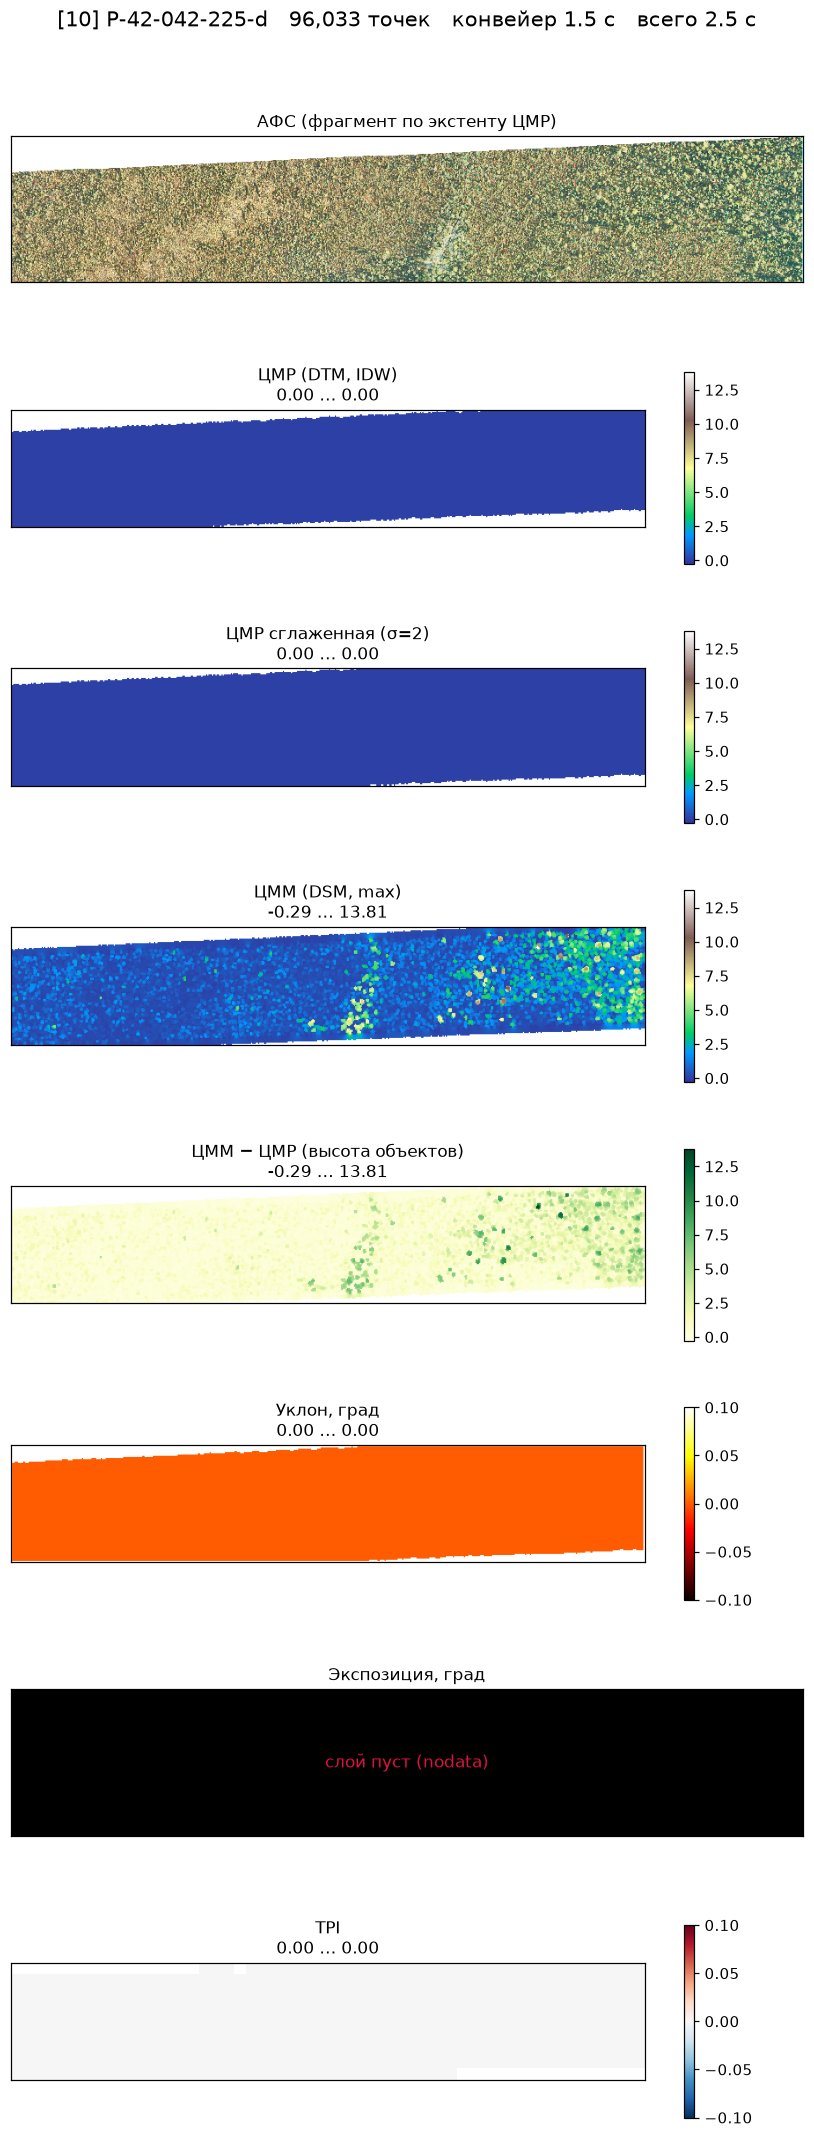


P-42-042-228-d.png


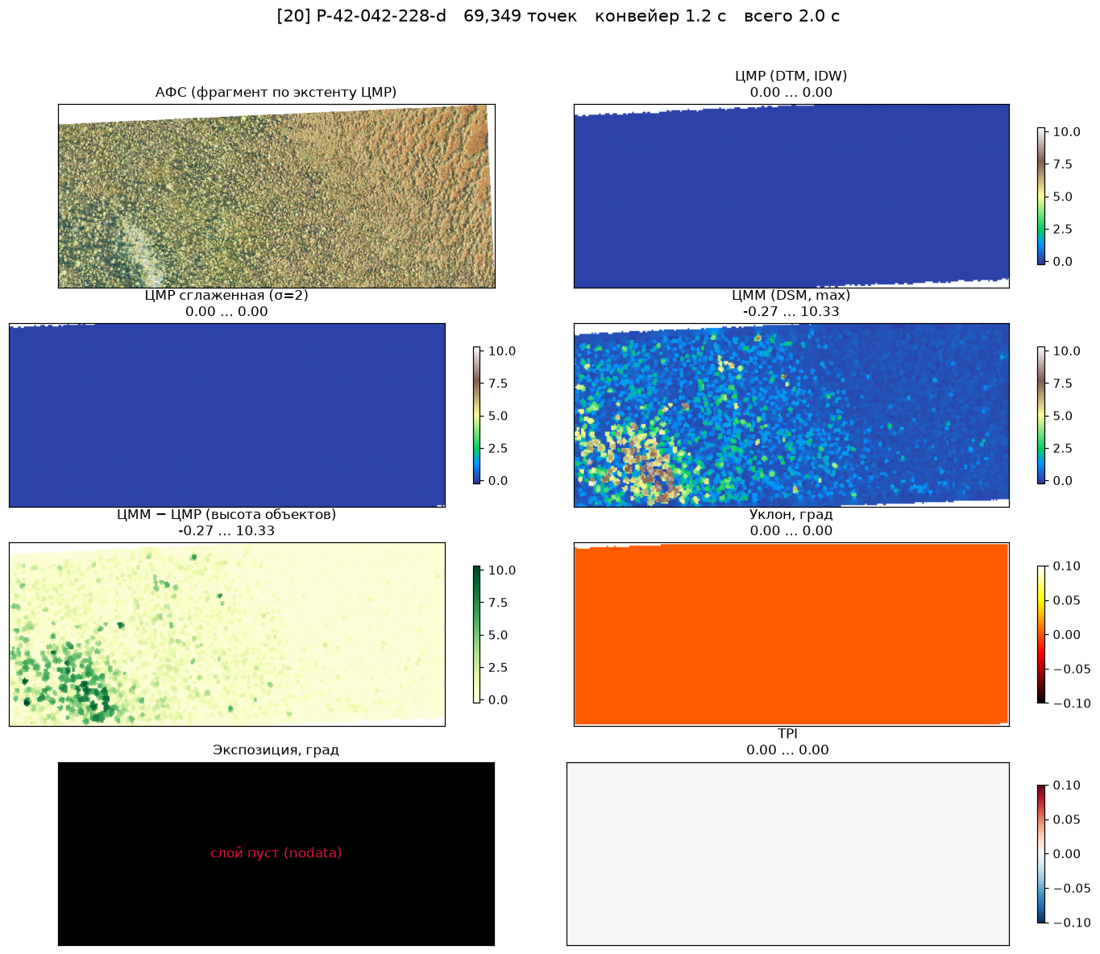


P-42-042-246-b.png


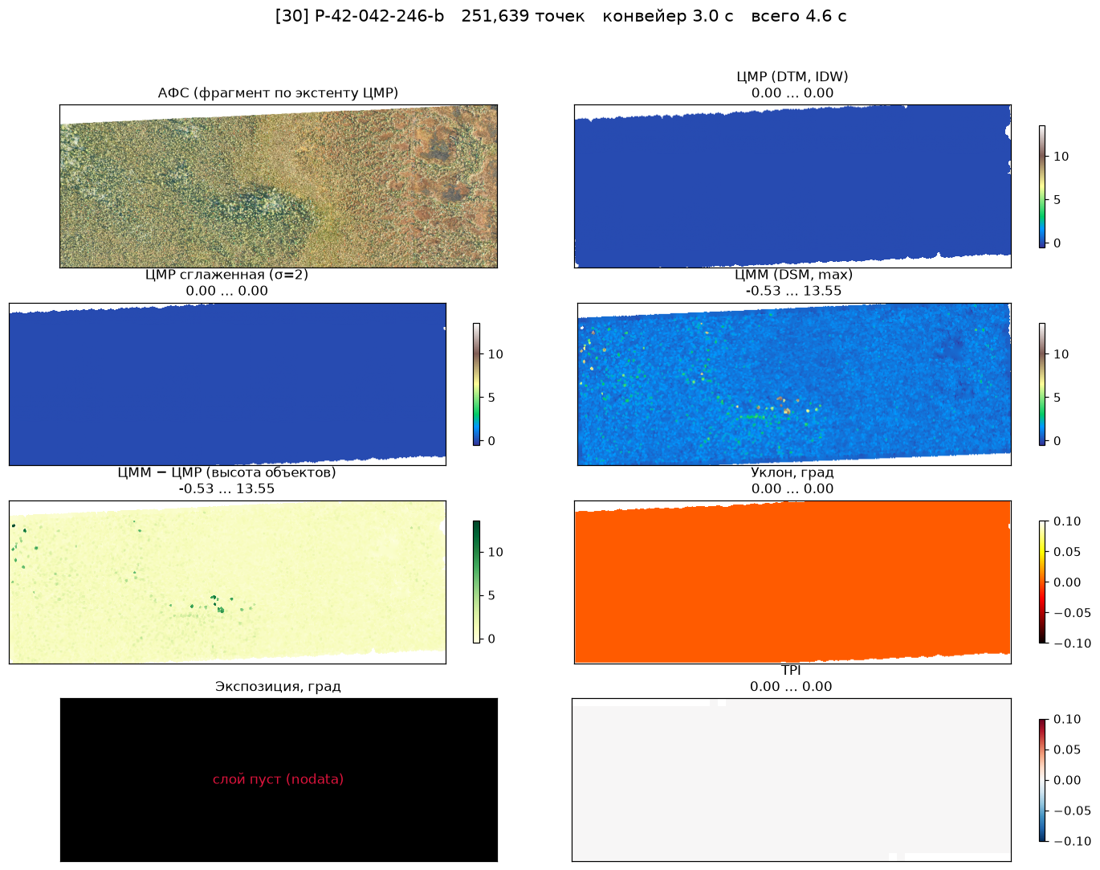


Остальные 7 — в каталоге превью.


In [8]:
import glob
from PIL import Image
from IPython.display import display

GALLERY_MAX   = 3      # сколько превью показать в ноутбуке
GALLERY_WIDTH = 1100   # px; полноразмерные лежат на диске

shots = sorted(glob.glob(str(PREVIEW_DIR / '*.png')))
print(f'Сохранено превью: {len(shots)} → {PREVIEW_DIR}')
if not shots:
    print('Превью пока нет: запустите прогон с RESUME = False или удалите JSONL.')
for path in shots[:GALLERY_MAX]:
    img = Image.open(path)
    if img.width > GALLERY_WIDTH:
        img = img.resize((GALLERY_WIDTH, round(img.height * GALLERY_WIDTH / img.width)))
    print(f'\n{os.path.basename(path)}')
    display(img)
if len(shots) > GALLERY_MAX:
    print(f'\nОстальные {len(shots) - GALLERY_MAX} — в каталоге превью.')


## . Сводная таблица по тайлам

Строка на тайл: объём облака, время загрузки и расчёта, состав выдачи. Дальше та
же таблица разбирается по срезам — время в целом, по шагам и по выходным слоям.


In [9]:
def tile_row(r):
    prep = r.get('prep', {})
    st = r.get('stats', {})
    row = {
        'tile': r['name'],
        'points': r.get('n_points'),
        'las_MB': round(r.get('las_size_mb', 0), 1),
        'density_pts_m2': r.get('las_points_density'),
        'las_area_km2': r.get('las_area_km2'),
        'download_s': prep.get('download_ms', 0) / 1000,
        'afs_hdr_s': prep.get('afs_header_ms', 0) / 1000,
        'assess_s': prep.get('assess_ms', 0) / 1000,
        'restore_s': prep.get('restore_ms', 0) / 1000,
        'pipeline_s': (r.get('tile_duration_ms') or 0) / 1000,
        'service_s': prep.get('service_wall_ms', 0) / 1000,
        'total_s': r.get('total_wall_ms', 0) / 1000,
        'dtm_z_min': st.get('dtm', {}).get('z_min'),
        'dtm_z_max': st.get('dtm', {}).get('z_max'),
        'dsm_z_max': st.get('dsm', {}).get('z_max'),
        'dtm_valid_%': st.get('dtm', {}).get('valid_pct'),
    }
    for s in RB.STEP_ORDER:
        row[f'ms_{s}'] = (r.get('steps', {}).get(s) or {}).get('ms')
    return row

df = pd.DataFrame([tile_row(r) for r in ok]).set_index('tile')
print(f'{len(df)} тайлов')
df[['points', 'las_MB', 'density_pts_m2', 'download_s', 'pipeline_s', 'total_s',
    'dtm_z_min', 'dtm_z_max', 'dsm_z_max', 'dtm_valid_%']].head(15).round(2)

100 тайлов


,points,las_MB,density_pts_m2,download_s,pipeline_s,total_s,dtm_z_min,dtm_z_max,dsm_z_max,dtm_valid_%
tile,,,,,,,,,,
P-42-041-239-e,87692,3.0,2.11,0.60,1.60,2.49,0.0,0.0,15.71,84.16
P-42-041-239-f,93422,3.2,2.13,0.80,1.52,2.61,0.0,0.0,17.96,84.99
P-42-041-239-g,1357837,46.2,3.05,6.98,16.96,24.23,0.0,0.0,21.63,95.55
P-42-041-239-h,1166858,39.7,2.62,6.12,14.12,20.59,0.0,0.0,20.61,95.71
P-42-041-240-d,85393,2.9,1.84,0.63,1.37,2.25,0.0,0.0,10.11,86.58
P-42-041-240-e,79162,2.7,1.63,0.45,1.29,2.03,0.0,0.0,3.21,86.43
P-42-041-240-f,83552,2.8,1.64,0.59,1.35,2.21,0.0,0.0,8.00,86.65
P-42-041-254-b,1568475,53.3,3.59,8.16,20.45,28.93,0.0,0.0,24.09,94.93
P-42-041-256-i,955826,32.5,2.14,5.60,10.73,16.65,0.0,0.0,16.20,95.41


## 7. Время: сводка и пропускная способность

`pipeline_s` — время конвейера по замерам сервиса, без сети.
`total_s` — полное время тайла, включая скачивание ВЛС и чтение заголовка АФС.

In [10]:
p, tot = df['pipeline_s'], df['total_s']
summary = pd.DataFrame({
    'конвейер, с': [p.min(), p.quantile(.25), p.median(), p.mean(),
                    p.quantile(.75), p.quantile(.95), p.max(), p.sum()],
    'всего (с сетью), с': [tot.min(), tot.quantile(.25), tot.median(), tot.mean(),
                           tot.quantile(.75), tot.quantile(.95), tot.max(), tot.sum()],
}, index=['min', 'p25', 'median', 'mean', 'p75', 'p95', 'max', 'СУММА']).round(2)

overhead = pd.DataFrame({
    'сумма, с': [df['download_s'].sum(), df['afs_hdr_s'].sum(), df['assess_s'].sum(),
                 df['restore_s'].sum(), p.sum()],
    'доля от total, %': [100 * df[c].sum() / tot.sum()
                         for c in ('download_s', 'afs_hdr_s', 'assess_s', 'restore_s')]
                        + [100 * p.sum() / tot.sum()],
}, index=['скачивание ВЛС', 'заголовок АФС', 'оценка материалов',
          'восстановление Z', 'конвейер']).round(2)

thr = pd.DataFrame({
    'на конвейер': [df['points'].sum() / p.sum() / 1e6,
                    df['las_MB'].sum() / p.sum(),
                    p.sum() / (df['points'].sum() / 1e6)],
    'с сетью': [df['points'].sum() / tot.sum() / 1e6,
                df['las_MB'].sum() / tot.sum(),
                tot.sum() / (df['points'].sum() / 1e6)],
}, index=['млн точек / с', 'МБ ВЛС / с', 'с на млн точек']).round(2)

display(summary, overhead, thr)
print(f"Обработано: {df['points'].sum() / 1e6:.1f} млн точек, "
      f"{df['las_MB'].sum() / 1024:.2f} ГБ ВЛС, {len(df)} тайлов")
print(f"Суммарно: конвейер {p.sum() / 60:.1f} мин, с сетью {tot.sum() / 60:.1f} мин")

,"конвейер, с","всего (с сетью), с"
min,1.02,1.74
p25,2.84,4.51
median,9.01,13.14
mean,7.39,10.98
p75,10.75,16.09
p95,13.28,20.32
max,20.45,28.93
СУММА,738.74,1098.42


,"сумма, с","доля от total, %"
скачивание ВЛС,325.06,29.59
заголовок АФС,26.16,2.38
оценка материалов,3.55,0.32
восстановление Z,0.00,0.00
конвейер,738.74,67.26


,на конвейер,с сетью
млн точек / с,0.08,0.06
МБ ВЛС / с,2.78,1.87
с на млн точек,12.22,18.16


Обработано: 60.5 млн точек, 2.01 ГБ ВЛС, 100 тайлов
Суммарно: конвейер 12.3 мин, с сетью 18.3 мин


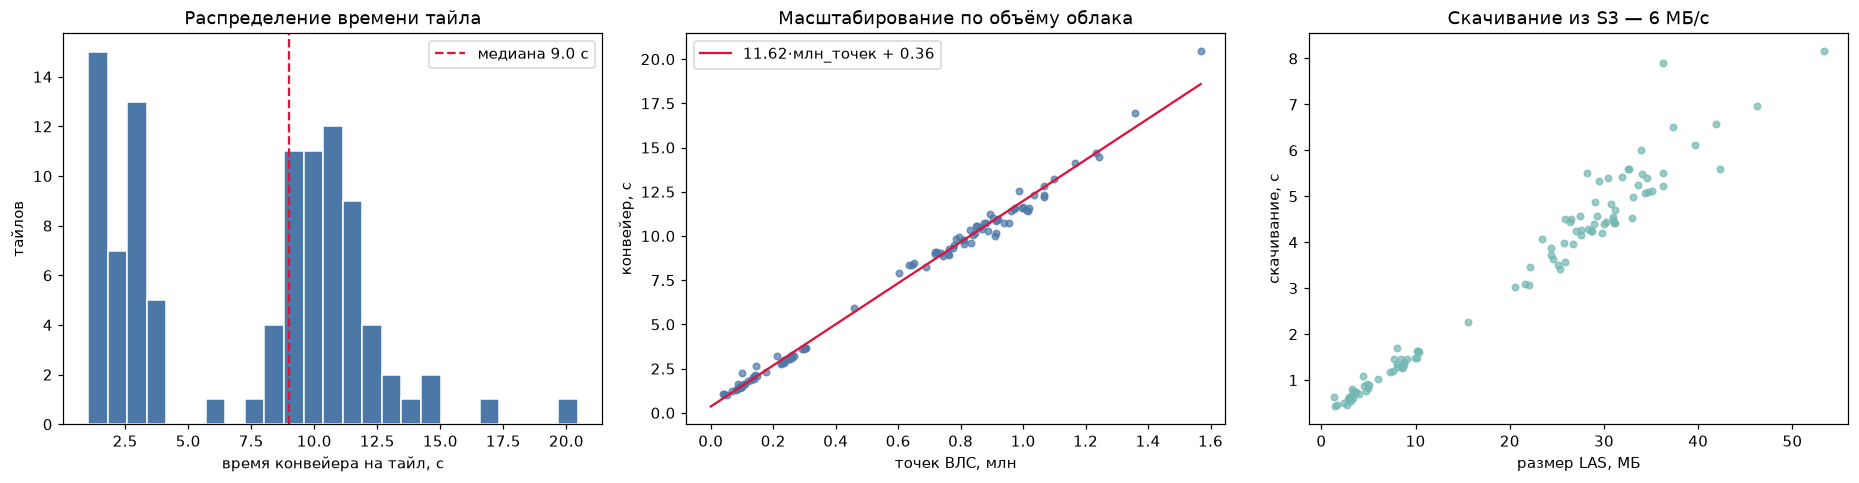

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(p, bins=25, color='#4C78A8', edgecolor='white')
axes[0].axvline(p.median(), color='crimson', ls='--', label=f'медиана {p.median():.1f} с')
axes[0].set_xlabel('время конвейера на тайл, с'); axes[0].set_ylabel('тайлов')
axes[0].set_title('Распределение времени тайла'); axes[0].legend()

x = df['points'] / 1e6
k = np.polyfit(x, p, 1)
xs = np.linspace(0, x.max(), 50)
axes[1].scatter(x, p, s=18, alpha=.7, color='#4C78A8')
axes[1].plot(xs, np.polyval(k, xs), color='crimson', lw=1.5,
             label=f'{k[0]:.2f}·млн_точек + {k[1]:.2f}')
axes[1].set_xlabel('точек ВЛС, млн'); axes[1].set_ylabel('конвейер, с')
axes[1].set_title('Масштабирование по объёму облака'); axes[1].legend()

axes[2].scatter(df['las_MB'], df['download_s'], s=18, alpha=.7, color='#72B7B2')
mb = df['las_MB'][df['download_s'] > 0]
if len(mb) > 1:
    sp = mb.sum() / df['download_s'][df['download_s'] > 0].sum()
    axes[2].set_title(f'Скачивание из S3 — {sp:.0f} МБ/с')
else:
    axes[2].set_title('Скачивание из S3')
axes[2].set_xlabel('размер LAS, МБ'); axes[2].set_ylabel('скачивание, с')

plt.tight_layout(); plt.show()

## 8. Время по шагам конвейера

Разбивка полного времени тайла: сеть, оценка материалов и каждый шаг расчёта
отдельно. Показывает, что упирается в загрузку, а что в вычисление.


In [12]:
step_cols = [f'ms_{s}' for s in RB.STEP_ORDER]
steps = df[step_cols].rename(columns=lambda c: c[3:])

step_summary = pd.DataFrame({
    'сумма, с': steps.sum() / 1000,
    'доля, %': 100 * steps.sum() / steps.sum().sum(),
    'медиана, мс': steps.median(),
    'среднее, мс': steps.mean(),
    'p95, мс': steps.quantile(.95),
    'max, мс': steps.max(),
}).sort_values('доля, %', ascending=False).round(2)
step_summary

,"сумма, с","доля, %","медиана, мс","среднее, мс","p95, мс","max, мс"
dtm,407.90,55.48,5067.5,4078.96,7526.00,11137
dsm,286.24,38.93,3416.5,2862.40,5199.25,8783
tpi,7.66,1.04,79.0,76.61,84.00,88
aspect,6.66,0.91,69.0,66.57,72.05,102
slope,6.63,0.90,69.0,66.27,72.00,84
tin,6.33,0.86,73.0,63.28,128.05,139
heights,6.14,0.83,71.0,61.35,124.00,135
smooth,5.89,0.80,66.0,58.93,82.15,117
contours,1.83,0.25,19.0,18.33,22.00,23
crop,0.00,0.00,0.0,0.00,0.00,0


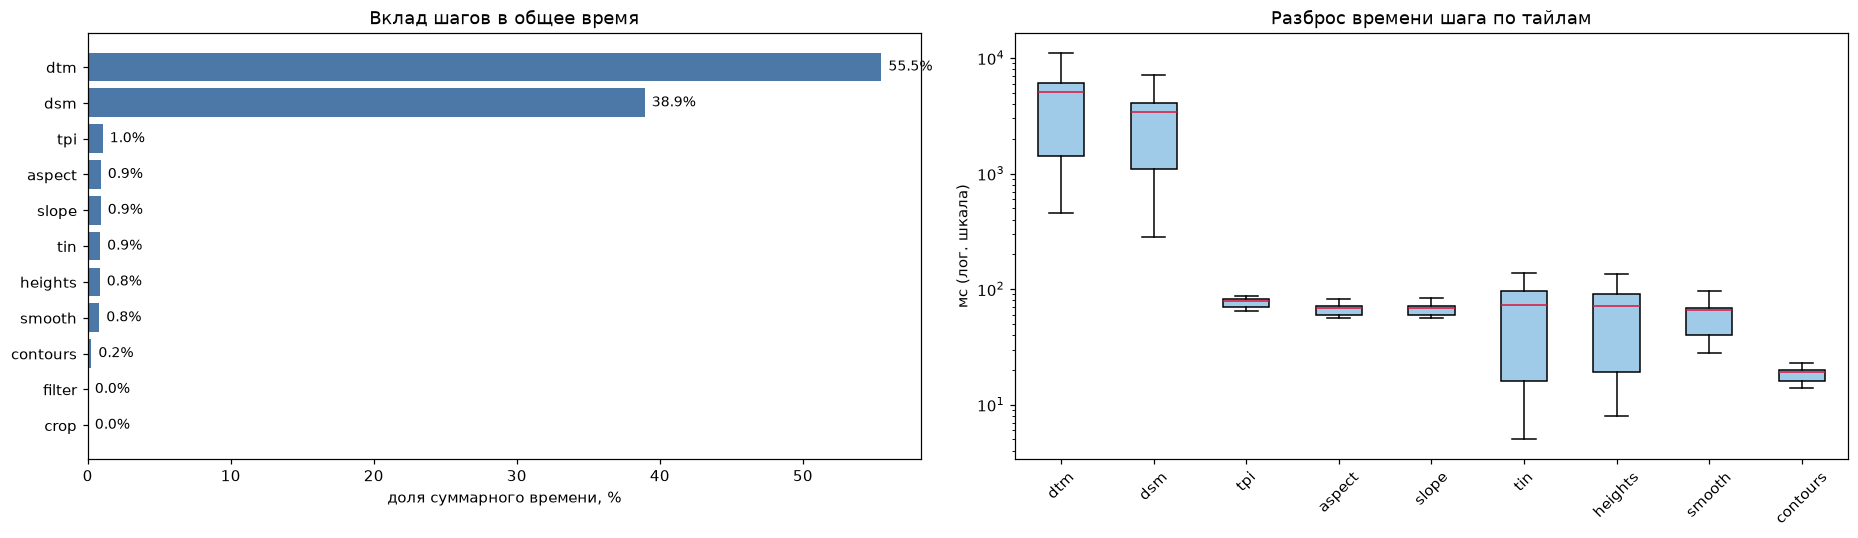

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

share = (steps.sum() / steps.sum().sum() * 100).sort_values()
axes[0].barh(share.index, share.values, color='#4C78A8')
for i, v in enumerate(share.values):
    axes[0].text(v + .5, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('доля суммарного времени, %')
axes[0].set_title('Вклад шагов в общее время')

order = [c for c in share.index[::-1] if steps[c].notna().any() and steps[c].sum() > 0]
axes[1].boxplot([steps[c].dropna() for c in order], tick_labels=order,
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#A0CBE8'), medianprops=dict(color='crimson'))
axes[1].set_yscale('log'); axes[1].set_ylabel('мс (лог. шкала)')
axes[1].set_title('Разброс времени шага по тайлам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

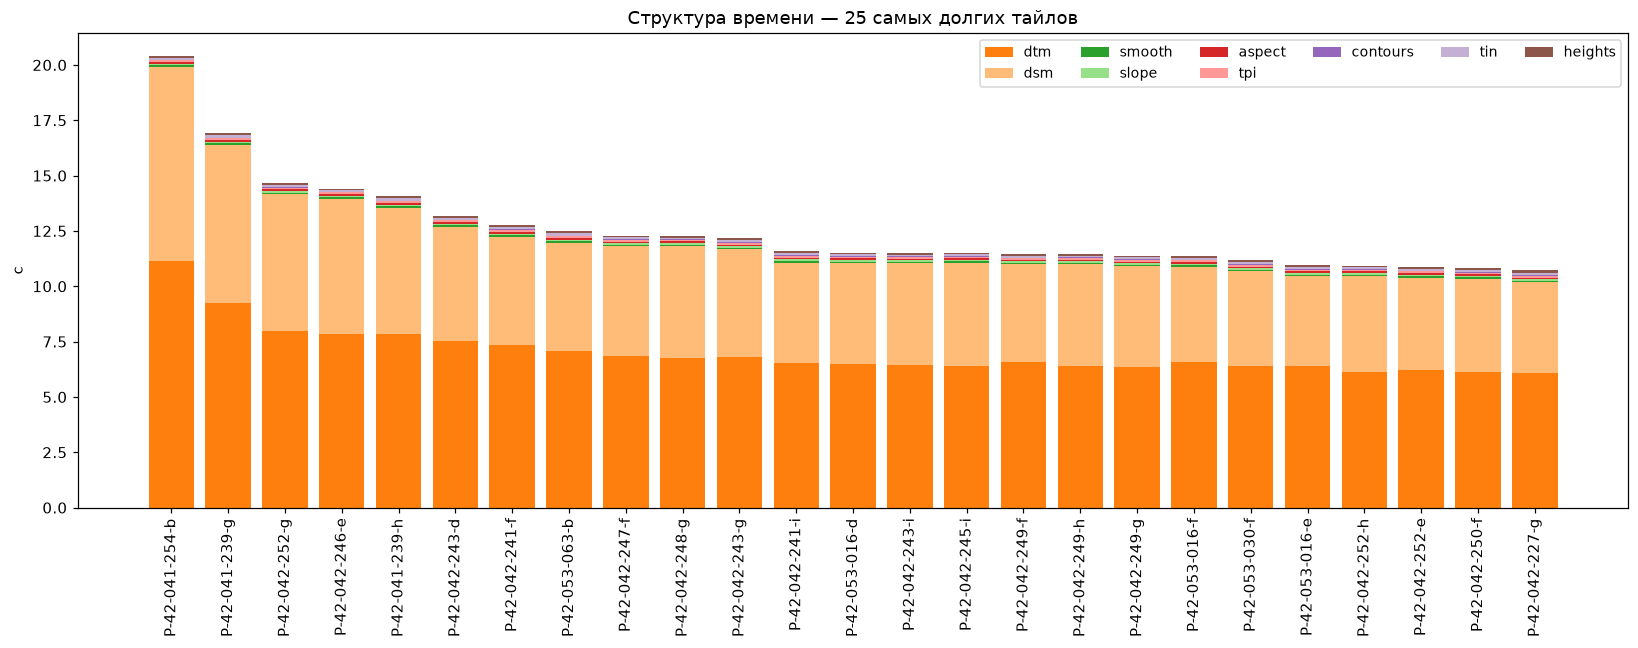

In [14]:
top = df.nlargest(min(25, len(df)), 'pipeline_s')
sub = top[step_cols].rename(columns=lambda c: c[3:]).fillna(0) / 1000

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(sub))
cmap = plt.get_cmap('tab20')
for i, c in enumerate(RB.STEP_ORDER):
    if c in sub and sub[c].sum() > 0:
        ax.bar(sub.index, sub[c], bottom=bottom, label=c, color=cmap(i % 20))
        bottom += sub[c].values
ax.set_ylabel('с'); ax.set_title(f'Структура времени — {len(sub)} самых долгих тайлов')
ax.tick_params(axis='x', rotation=90)
ax.legend(ncol=6, fontsize=9)
plt.tight_layout(); plt.show()

## 9. Время и размер по каждому выходному результату

Время привязано к породившему шагу. `dtm` и `ground_las` выходят из одного шага
`dtm`, четыре шейпфайла горизонталей — из одного шага `contours`, поэтому время
агрегируется по уникальным парам (тайл, шаг), а размеры — по файлам.

In [15]:
rows = [{'tile': r['name'], 'layer': a['layer'], 'kind': a['kind'], 'file': a['file'],
         'step': a['step'], 'ms': a['step_ms'], 'size_kb': (a['size_bytes'] or 0) / 1024}
        for r in ok for a in r.get('artifacts', [])]
arts = pd.DataFrame(rows)

size_agg = arts.groupby('layer').agg(
    файлов=('file', 'count'), формат=('kind', 'first'), шаг=('step', 'first'),
    медиана_KB=('size_kb', 'median'), сумма_MB=('size_kb', lambda s: s.sum() / 1024))
time_agg = (arts.drop_duplicates(subset=['tile', 'step']).groupby('step')['ms']
            .agg(медиана_мс='median', среднее_мс='mean',
                 p95_мс=lambda s: s.quantile(.95), сумма_с=lambda s: s.sum() / 1000))

by_layer = size_agg.join(time_agg, on='шаг').sort_values('сумма_с', ascending=False).round(2)
by_layer['примечание'] = np.where(
    by_layer.groupby('шаг')['шаг'].transform('size') > 1,
    'время делится с др. слоями того же шага', '')
by_layer

,файлов,формат,шаг,медиана_KB,сумма_MB,медиана_мс,среднее_мс,p95_мс,сумма_с,примечание
layer,,,,,,,,,,
dtm,100,geotiff,dtm,1742.24,119.26,5067.5,4078.96,7526.00,407.90,время делится с др. слоями того же шага
ground_las,100,las,dtm,26066.65,2076.32,5067.5,4078.96,7526.00,407.90,время делится с др. слоями того же шага
dsm,100,geotiff,dsm,1747.99,119.84,3416.5,2862.40,5199.25,286.24,
tpi,100,geotiff,tpi,18.67,1.32,79.0,76.61,84.00,7.66,
aspect,100,geotiff,aspect,1742.24,119.26,69.0,66.57,72.05,6.66,
slope,100,geotiff,slope,1742.24,119.26,69.0,66.27,72.00,6.63,
tin,100,dxf,tin,708.51,48.56,73.0,63.28,128.05,6.33,
heights,100,shp,heights,75.93,5.22,71.0,61.35,124.00,6.14,
dtm_smooth,100,geotiff,smooth,1740.01,119.09,66.0,58.93,82.15,5.89,


## 10. Итог


In [16]:
print(f'Датасет:            Юильский, {len(PAIRS)} пар АФС+ВЛС в бакете {BUCKET}')
print(f'Обработано:         {len(ok)} тайлов (ошибок {len(bad)}), '
      f'{df["points"].sum() / 1e6:.1f} млн точек, {df["las_MB"].sum() / 1024:.2f} ГБ ВЛС')
print(f'Режим Z:            {"абсолютные (восстановлены по эталону)" if RESTORE_ABSOLUTE_Z else "ТЛО (как в исходном LAS)"}')
print(f'Время конвейера:    медиана {p.median():.1f} с, p95 {p.quantile(.95):.1f} с, '
      f'сумма {p.sum() / 60:.1f} мин')
print(f'Время с сетью:      медиана {tot.median():.1f} с, сумма {tot.sum() / 60:.1f} мин '
      f'(скачивание {100 * df["download_s"].sum() / tot.sum():.0f} % от общего)')
print(f'Пропускная спос.:   {df["points"].sum() / p.sum() / 1e6:.2f} млн точек/с на конвейере')
print(f'Самый дорогой шаг:  {step_summary.index[0]} — {step_summary.iloc[0]["доля, %"]:.0f} % времени')
print(f'Картинок сохранено: {len(list(PREVIEW_DIR.glob("*.png")))} → {PREVIEW_DIR}')
print(f'JSONL:              {RESULTS_PATH}')

Датасет:            Юильский, 598 пар АФС+ВЛС в бакете geomate-project
Обработано:         100 тайлов (ошибок 0), 60.5 млн точек, 2.01 ГБ ВЛС
Режим Z:            ТЛО (как в исходном LAS)
Время конвейера:    медиана 9.0 с, p95 13.3 с, сумма 12.3 мин
Время с сетью:      медиана 13.1 с, сумма 18.3 мин (скачивание 30 % от общего)
Пропускная спос.:   0.08 млн точек/с на конвейере
Самый дорогой шаг:  dtm — 55 % времени
Картинок сохранено: 10 → /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_yuilskiy/previews
JSONL:              /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_yuilskiy/results.jsonl
